In [5]:
import os
import glob
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
import glob, os

CARPETA_PRUEBAS = "PruebasF"
print(glob.glob(os.path.join(CARPETA_PRUEBAS, "*.jpg")))

# ================= CONFIGURACIÓN =================
CARPETA_PRUEBAS = "pruebas_reales"
MODELO_RESNET = "resnet50_extractor.pth"
MODELO_LDA = "lda_classifier.joblib"

CLASES = [
    'battery', 'biological', 'brown-glass', 'cardboard', 'clothes',
    'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass'
]

# ================= DISPOSITIVO =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# ================= TRANSFORMACIONES =================
transformacion = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ================= CARGA DEL SISTEMA =================
def cargar_sistema():
    print("Cargando sistema híbrido (ResNet + LDA)...")

    # -------- ResNet Extractor --------
    if not os.path.exists(MODELO_RESNET):
        print("❌ No se encontró el modelo ResNet")
        return None, None

    extractor = models.resnet50(weights=None)
    extractor.fc = nn.Identity()  # Quitar capa final

    # 🔥 FIX PyTorch 2.6+ (weights_only=False)
    state_dict = torch.load(
        MODELO_RESNET,
        map_location=device,
        weights_only=False
    )

    extractor.load_state_dict(state_dict)
    extractor.to(device)
    extractor.eval()

    # -------- LDA Classifier --------
    if not os.path.exists(MODELO_LDA):
        print("❌ No se encontró el modelo LDA")
        return None, None

    lda = joblib.load(MODELO_LDA)

    print("✅ Modelos cargados correctamente")
    return extractor, lda

# ================= EJECUCIÓN DE PRUEBAS =================
def ejecutar_pruebas():
    extractor, clasificador = cargar_sistema()
    if extractor is None or clasificador is None:
        return

    # Buscar imágenes
    imagenes = []
    extensiones = ("*.jpg", "*.jpeg", "*.png", "*.webp",
                   "*.JPG", "*.JPEG", "*.PNG", "*.WEBP", "*.jfif")

    for ext in extensiones:
        imagenes.extend(
            glob.glob(os.path.join(CARPETA_PRUEBAS, "**", ext), recursive=True)
        )

    if not imagenes:
        print("❌ No se encontraron imágenes en la carpeta de pruebas")
        return

    cols = 4
    rows = (len(imagenes) // cols) + 1
    plt.figure(figsize=(16, 5 * rows))

    print(f"📷 Procesando {len(imagenes)} imágenes...")

    for i, ruta in enumerate(imagenes):
        try:
            img = Image.open(ruta).convert('RGB')
            tensor = transformacion(img).unsqueeze(0).to(device)

            # -------- Extracción de características --------
            with torch.no_grad():
                feature_vector = extractor(tensor).cpu().numpy()

            # -------- Clasificación LDA --------
            probs = clasificador.predict_proba(feature_vector)[0]
            pred_idx = clasificador.predict(feature_vector)[0]

            clase = CLASES[pred_idx]
            confianza = probs[pred_idx] * 100

            # -------- Visualización --------
            ax = plt.subplot(rows, cols, i + 1)
            ax.imshow(img)
            ax.axis('off')

            color = 'green' if confianza > 70 else 'red'
            ax.set_title(
                f"{os.path.basename(ruta)}\n{clase} ({confianza:.1f}%)",
                color=color,
                fontsize=10,
                fontweight='bold'
            )

            print(f"✔ {os.path.basename(ruta)} → {clase} ({confianza:.1f}%)")

        except Exception as e:
            print(f"❌ Error procesando {ruta}: {e}")

    plt.tight_layout()
    plt.show()

# ================= MAIN =================
if __name__ == "__main__":
    ejecutar_pruebas()


[]
Usando dispositivo: cpu
Cargando sistema híbrido (ResNet + LDA)...
✅ Modelos cargados correctamente
❌ No se encontraron imágenes en la carpeta de pruebas


In [6]:
import os

CARPETA_PRUEBAS = "PruebasF"

print("Ruta absoluta de la carpeta:")
print(os.path.abspath(CARPETA_PRUEBAS))

print("\nContenido REAL que ve Python:")
for root, dirs, files in os.walk(CARPETA_PRUEBAS):
    print("📂", root)
    print("   📄 archivos:", files)
    print("   📁 subcarpetas:", dirs)


Ruta absoluta de la carpeta:
c:\Users\adpp1\OneDrive\Documentos\Adaniel\Personal\6AV1\Modelado Predictivo\PruebasF

Contenido REAL que ve Python:
📂 PruebasF
   📄 archivos: []
   📁 subcarpetas: ['PruebasF']
📂 PruebasF\PruebasF
   📄 archivos: ['1.jpg', '2.jpg', 'B1.HEIC', 'B2.HEIC', 'IMG_2829.HEIC', 'IMG_2831.HEIC', 'IMG_2832.HEIC', 'IMG_3452.JPG', 'IMG_3453.JPG', 'IMG_3454.JPG']
   📁 subcarpetas: []


Usando dispositivo: cpu
Cargando sistema híbrido (ResNet + LDA)...
✅ Modelos cargados correctamente
📷 Imágenes encontradas: 5
✔ 1.jpg → metal (100.0%)
✔ 2.jpg → paper (100.0%)
✔ IMG_3452.JPG → metal (100.0%)
✔ IMG_3453.JPG → plastic (96.0%)
✔ IMG_3454.JPG → white-glass (100.0%)


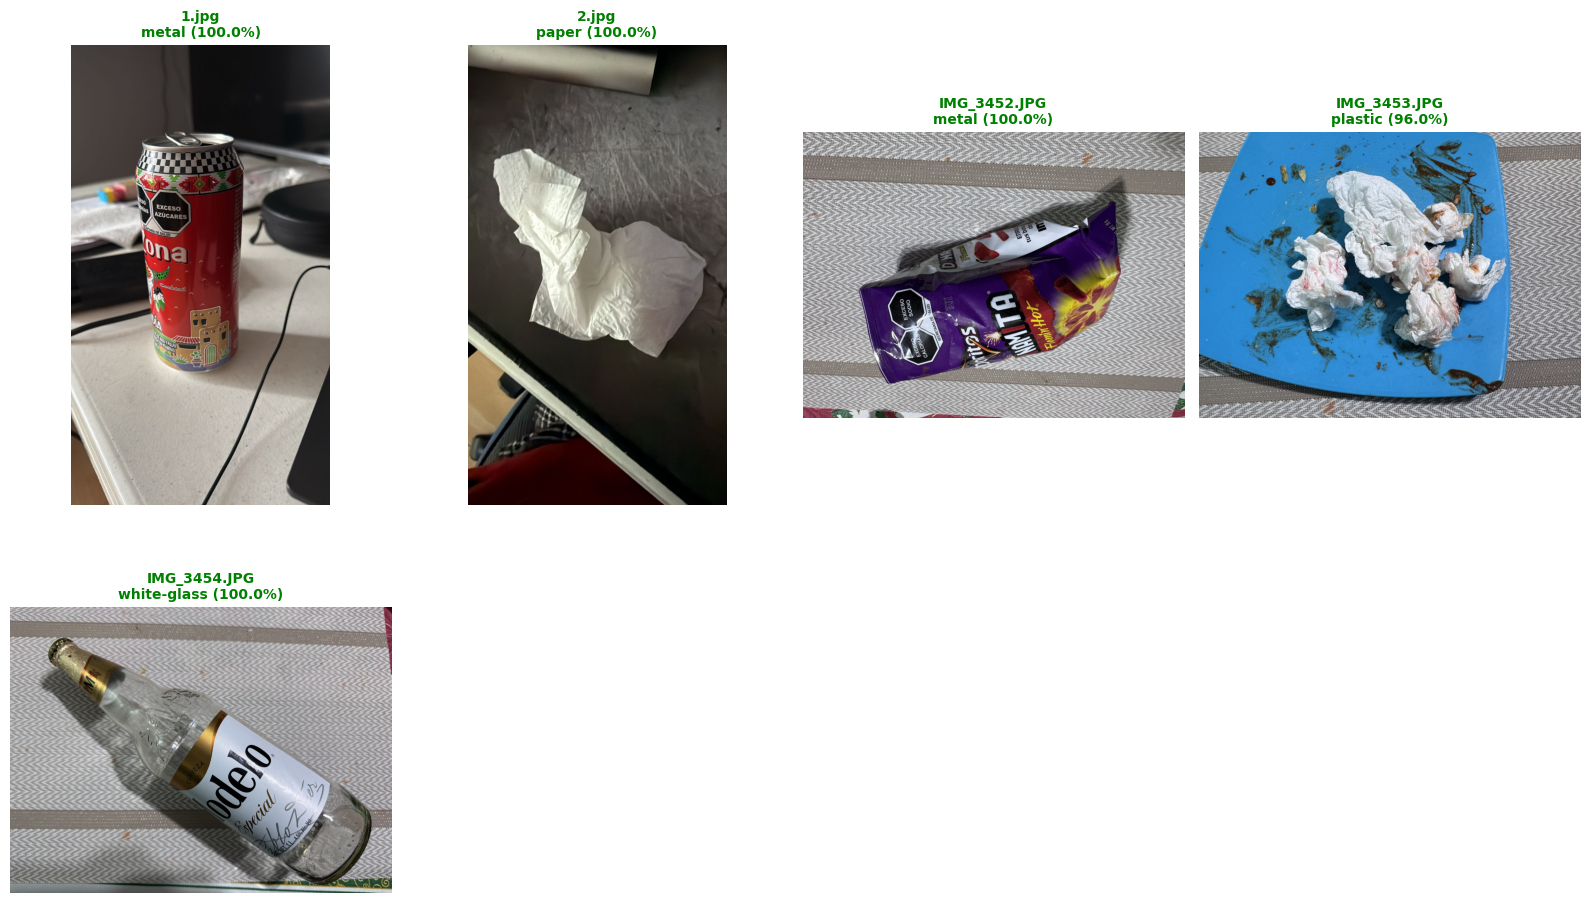

In [7]:
import os
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image

# ================= CONFIGURACIÓN =================

# ⚠️ RUTA CORRECTA (carpeta dentro de carpeta)
CARPETA_PRUEBAS = r"PruebasF\PruebasF"

MODELO_RESNET = "resnet50_extractor.pth"
MODELO_LDA = "lda_classifier.joblib"

CLASES = [
    'battery', 'biological', 'brown-glass', 'cardboard', 'clothes',
    'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass'
]

# ================= DISPOSITIVO =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# ================= TRANSFORMACIONES =================
transformacion = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ================= CARGA DEL SISTEMA =================
def cargar_sistema():
    print("Cargando sistema híbrido (ResNet + LDA)...")

    # -------- ResNet Extractor --------
    if not os.path.exists(MODELO_RESNET):
        print("❌ No se encontró el modelo ResNet")
        return None, None

    extractor = models.resnet50(weights=None)
    extractor.fc = nn.Identity()

    state_dict = torch.load(
        MODELO_RESNET,
        map_location=device,
        weights_only=False  # FIX PyTorch 2.6+
    )

    extractor.load_state_dict(state_dict)
    extractor.to(device)
    extractor.eval()

    # -------- LDA --------
    if not os.path.exists(MODELO_LDA):
        print("❌ No se encontró el modelo LDA")
        return None, None

    lda = joblib.load(MODELO_LDA)

    print("✅ Modelos cargados correctamente")
    return extractor, lda

# ================= EJECUCIÓN =================
def ejecutar_pruebas():
    extractor, clasificador = cargar_sistema()
    if extractor is None or clasificador is None:
        return

    # -------- Buscar imágenes (robusto) --------
    imagenes = []
    for file in os.listdir(CARPETA_PRUEBAS):
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            imagenes.append(os.path.join(CARPETA_PRUEBAS, file))

    if not imagenes:
        print("❌ No se encontraron imágenes en la carpeta de pruebas")
        return

    print(f"📷 Imágenes encontradas: {len(imagenes)}")

    cols = 4
    rows = (len(imagenes) // cols) + 1
    plt.figure(figsize=(16, 5 * rows))

    for i, ruta in enumerate(imagenes):
        try:
            img = Image.open(ruta).convert('RGB')
            tensor = transformacion(img).unsqueeze(0).to(device)

            # -------- Extracción --------
            with torch.no_grad():
                features = extractor(tensor).cpu().numpy()

            # -------- Clasificación --------
            probs = clasificador.predict_proba(features)[0]
            pred_idx = clasificador.predict(features)[0]

            clase = CLASES[pred_idx]
            confianza = probs[pred_idx] * 100

            # -------- Visualización --------
            ax = plt.subplot(rows, cols, i + 1)
            ax.imshow(img)
            ax.axis('off')

            color = 'green' if confianza > 70 else 'red'
            ax.set_title(
                f"{os.path.basename(ruta)}\n{clase} ({confianza:.1f}%)",
                color=color,
                fontsize=10,
                fontweight='bold'
            )

            print(f"✔ {os.path.basename(ruta)} → {clase} ({confianza:.1f}%)")

        except Exception as e:
            print(f"❌ Error procesando {ruta}: {e}")

    plt.tight_layout()
    plt.show()

# ================= MAIN =================
if __name__ == "__main__":
    ejecutar_pruebas()
